# SIG720 - Machine Learning: Task 8D
## Mini Project: Sydney Housing Price Prediction and Decision Support System

## Project Title: SydValuat_AI | Sydney Housing Price Prediction & Market Intelligence


#### **Repository:** https://github.com/ayubsmg16/SydValuat_AI

| | |
|---|---|
| **Ayuba Sule**
| **Student ID: 226653319**
| **School of Information Technology, Deakin University**
| **SIG720: Machine Learning**
| **August 23, 2026**

---

This notebook implements the complete machine-learning lifecycle for predicting residential sale
prices across three contrasting Sydney suburbs — Mosman, Marrickville, and Blacktown — using 100
manually collected sold-property records. It covers data loading and integrity checks, data
cleaning and quality assessment, leakage-aware feature engineering, exploratory analysis on the
training partition only, development and k-fold cross-validated comparison of three modelling
families, hyperparameter optimisation, final model selection and hold-out evaluation, model
interpretation, conformal-style prediction intervals, investigation of the largest prediction
failures, the Part 5 human-vs-LLM-vs-ML scaffolding, and export of the trained pipeline and
metadata for the Streamlit decision-support application (Deliverable 3).

**Reproducibility note.** Every metric, table, and narrative number in this notebook is computed
at runtime from the actual dataset — nothing is hard-coded — so re-running the notebook always
produces internally consistent results. A fixed random seed (`RANDOM_STATE = 42`) is used
throughout.

## 0. Environment Setup

The notebook runs unchanged in Google Colab or locally. In Colab, uncomment the Drive mount below.
The data-path resolver in Section 1 tries the Google Drive location first, then a local copy, and
finally falls back to the raw file in the public GitHub repository, so the notebook remains
executable in any of the three environments.

In [1]:
import os, json, warnings, platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import joblib

!pip -q install shap   # optional: enables the SHAP cell in Section 11

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print(f"Python        : {platform.python_version()}")
print(f"numpy         : {np.__version__}")
print(f"pandas        : {pd.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")
print(f"Run timestamp : {datetime.now().isoformat(timespec='seconds')}")

Python        : 3.12.13
numpy         : 2.0.2
pandas        : 2.2.2
scikit-learn  : 1.6.1
Run timestamp : 2026-08-18T15:10:46


## 1. Data Loading

The dataset (`Property_Sales_Dataset.csv`) contains sold-property records collected manually from
publicly available listings on realestate.com.au between February and July 2026. No scraping or
synthetic generation was used; every row corresponds to a real, verifiable sold listing whose
`source_url` is retained for provenance. The resolver below locates the file in whichever
environment the notebook is running.

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ---------------------------------------------------------
# Data source configuration
# ---------------------------------------------------------

# Primary source: GitHub
GITHUB_RAW = (
    "https://raw.githubusercontent.com/ayubsmg16/SydValuat_AI/"
    "main/data/raw/Property_Sales_Dataset.csv"
)

# Fallback sources
CANDIDATE_PATHS = [
    "/content/drive/MyDrive/MSc Program/Deakin University/SIG720_ML/8D_Mini Project/Property_Sales_Dataset.csv",
    "data/Property_Sales_Dataset.csv",
    "Property_Sales_Dataset.csv",
]

# ---------------------------------------------------------
# Load dataset - GitHub first, local/Drive as fallback
# ---------------------------------------------------------

try:
    print(f"Loading data from GitHub: {GITHUB_RAW}")
    raw = pd.read_csv(GITHUB_RAW)
    data_path = GITHUB_RAW

except Exception as e:
    print(f"GitHub load failed: {e}")
    print("Searching fallback locations...")

    data_path = next(
        (p for p in CANDIDATE_PATHS if os.path.exists(p)),
        None
    )

    if data_path is None:
        raise FileNotFoundError(
            "Dataset could not be loaded from GitHub and "
            "was not found in any fallback location."
        )

    print(f"Loading fallback data from: {data_path}")

    raw = (
        pd.read_excel(data_path)
        if str(data_path).lower().endswith((".xlsx", ".xls"))
        else pd.read_csv(data_path)
    )

# ---------------------------------------------------------
# Verify loaded dataset
# ---------------------------------------------------------

print(f"\nData source     : {data_path}")
print(f"Raw file shape  : {raw.shape[0]:,} rows x {raw.shape[1]} columns")

raw.head(3)

Loading data from GitHub: https://raw.githubusercontent.com/ayubsmg16/SydValuat_AI/main/data/raw/Property_Sales_Dataset.csv

Data source     : https://raw.githubusercontent.com/ayubsmg16/SydValuat_AI/main/data/raw/Property_Sales_Dataset.csv
Raw file shape  : 161 rows x 28 columns


,property_id,suburb,postcode,address,sale_price ($),sale_date,property_type,bedrooms,bathrooms,car_spaces,...,distance_to_station_km,distance_to_school_km,distance_to_shops_km,pool,renovated,water_view,Garden,property_condition,listing_agency,source_url
0,"151,189,284.00",Mosman,"2,088.00","142/15 Hale Road, Mosman, NSW 2088","$3,800,000",24/07/2026,House,3.00,2.00,2.00,...,NaN,0.15,NaN,No,NaN,NaN,No,NaN,RayWhite,https://www.realestate.com.au/sold/property-re...
1,"151,449,168.00",Mosman,"2,088.00","8/6 Punch Street, Mosman, NSW 2088","$700,000",20/07/2026,Unit,1.00,1.00,2.00,...,NaN,0.36,NaN,No,NaN,NaN,No,NaN,RayWhite,https://www.realestate.com.au/sold/property-ap...
2,"150,195,184.00",Mosman,"2,088.00","5 Botanic Road, Mosman, NSW 2088","$8,700,000",22/07/2026,House,4.00,3.00,2.00,...,NaN,0.46,NaN,Yes,NaN,NaN,No,NaN,Simeon Partner,https://www.realestate.com.au/sold/property-ho...


## 2. Data Cleaning and Quality Assessment

Manually collected real-estate data is inevitably imperfect, and the brief asks for the data's
quality, limitations, and biases to be assessed honestly rather than hidden. This section
documents, inside the pipeline itself, every cleaning decision taken: removal of empty
spreadsheet-export rows, parsing of currency and date fields, standardisation of inconsistent
category labels, duplicate checks, a missingness triage that determines which columns are usable,
and a semantic audit that uncovers a genuine labelling problem in one of the distance columns.

In [4]:
df = raw.copy()

# --- 2.1 Remove empty padding rows (Excel-export artefact) -------------------
blank_mask = df["property_id"].isna()
n_blank = int(blank_mask.sum())
df = df[~blank_mask].copy()
print(f"Removed {n_blank} completely empty padding rows (spreadsheet-export artefact).")
print(f"Real property records: {len(df)}")

# --- 2.2 Parse currency and date fields --------------------------------------
df["sale_price"] = (df["sale_price ($)"].astype(str)
                      .str.replace(r"[^0-9.]", "", regex=True).astype(float))
df["sale_date"] = pd.to_datetime(df["sale_date"], format="%d/%m/%Y")
assert df["sale_price"].notna().all(), "Unparseable sale prices detected"

# --- 2.3 Standardise inconsistent category labels ----------------------------
before = sorted(df["property_type"].unique().tolist())
df["property_type"] = df["property_type"].str.strip().str.title()
after = sorted(df["property_type"].unique().tolist())
print(f"\nproperty_type labels before standardisation: {before}")
print(f"property_type labels after  standardisation: {after}")

# --- 2.4 Duplicate detection --------------------------------------------------
print(f"\nDuplicate property_id values : {int(df['property_id'].duplicated().sum())}")
print(f"Duplicate addresses          : {int(df['address'].duplicated().sum())}")

# --- 2.5 Suburb balance -------------------------------------------------------
print("\nRecords per suburb (brief requires >= 30 each):")
print(df["suburb"].value_counts().to_string())

Removed 61 completely empty padding rows (spreadsheet-export artefact).
Real property records: 100

property_type labels before standardisation: ['Duplex', 'House', 'Townhouse', 'Unit', 'house']
property_type labels after  standardisation: ['Duplex', 'House', 'Townhouse', 'Unit']

Duplicate property_id values : 0
Duplicate addresses          : 0

Records per suburb (brief requires >= 30 each):
suburb
Marrickville    34
Mosman          33
Blacktown       33


### 2.6 Missingness Triage

The table below reports, for the 100 real records, the proportion of missing values per column.
Several fields could only rarely be recovered from public listings. Two distinct mechanisms are at
work. For measured attributes such as `building_size_m2` or `year_built`, missingness means the
listing simply did not publish the figure. For amenity flags such as `pool`, `Study`, and
`Garden`, a blank means *not stated* — which is not the same as *absent* — so imputing "No" would
inject a systematic error. Columns are therefore triaged with a transparent rule: any column
missing in 50% or more of records is excluded from modelling, with the exclusion documented rather
than silently imputed. `days_on_market` would additionally be excluded on data-leakage grounds
even if populated, because it is only observable after the sale process concludes.

In [5]:
miss = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
miss_tbl = miss.to_frame("missing_%")
print(miss_tbl.to_string())

DROP_MISSING = miss[miss >= 50].index.tolist()
DROP_LEAKAGE = ["days_on_market"]           # post-outcome information
DROP_IDENT   = ["property_id", "address", "source_url", "listing_agency",
                "postcode", "sale_price ($)"]  # identifiers / redundant encodings

drop_cols = sorted(set(DROP_MISSING) | set(DROP_LEAKAGE) | set(DROP_IDENT) & set(df.columns))
print(f"\nColumns excluded (>=50% missing): {sorted(set(DROP_MISSING))}")
print(f"Columns excluded (leakage)      : {DROP_LEAKAGE}")
print(f"Columns excluded (identifiers / redundant): {sorted(set(DROP_IDENT))}")

keep_for_ref = ["property_id", "address", "source_url"]   # retained separately for provenance
ref = df[keep_for_ref].copy()
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f"\nWorking columns after triage: {df.columns.tolist()}")

                        missing_%
water_view                 100.00
renovated                  100.00
distance_to_shops_km       100.00
distance_to_station_km     100.00
days_on_market             100.00
property_condition         100.00
auction_sale                97.00
year_built                  91.00
pool                        88.00
Study                       75.00
building_size_m2            73.00
Storeys                     71.00
Garden                      58.00
land_size_m2                 7.00
distance_to_cbd_km           3.00
car_spaces                   0.00
property_type                0.00
sale_date                    0.00
postcode                     0.00
address                      0.00
sale_price ($)               0.00
property_id                  0.00
suburb                       0.00
bedrooms                     0.00
bathrooms                    0.00
distance_to_school_km        0.00
listing_agency               0.00
source_url                   0.00
sale_price    

### 2.7 Semantic Audit: the `distance_to_cbd_km` Column

Cleaning is not only about missing values — it is also about checking that columns mean what their
names claim. The recorded values of `distance_to_cbd_km` fall between roughly 0 and 1.3 km for
**all three suburbs**, yet the true road distances to the Sydney CBD are approximately 8 km from
Mosman, 9 km from Marrickville, and 35 km from Blacktown. The column therefore cannot record
distance to the CBD; the values are consistent with proximity to a *local* hub (the suburb's own
centre or nearest station precinct), most likely reflecting how the figure was read off listing
pages during manual collection. Rather than discarding a fully usable micro-location signal, the
column is renamed `local_centre_km` so that its semantics are honest, and the discovery is
reported as a data-quality finding. This is exactly the kind of issue the brief anticipates when it
asks for challenges and limitations of manual collection to be discussed.

In [6]:
audit = df.groupby("suburb")["distance_to_cbd_km"].agg(["count", "min", "median", "max"]).round(2)
true_cbd = {"Mosman": 8, "Marrickville": 9, "Blacktown": 35}
audit["approx_true_cbd_km"] = audit.index.map(true_cbd)
print("Recorded values vs. true approximate CBD road distance:")
print(audit.to_string())

df = df.rename(columns={"distance_to_cbd_km": "local_centre_km"})
print("\nColumn renamed: distance_to_cbd_km -> local_centre_km "
      "(values represent proximity to a local hub, not the Sydney CBD).")

Recorded values vs. true approximate CBD road distance:
              count  min  median  max  approx_true_cbd_km
suburb                                                   
Blacktown        33 0.04    0.45 1.03                  35
Marrickville     34 0.00    0.24 0.81                   9
Mosman           30 0.03    0.22 1.28                   8

Column renamed: distance_to_cbd_km -> local_centre_km (values represent proximity to a local hub, not the Sydney CBD).


### 2.8 Land Size for Strata Properties

A second semantic issue affects `land_size_m2`. For houses the figure is the lot size, but for
units the listing typically reports the area of the **entire strata site** (a unit in a large
complex can show several thousand square metres of "land" that it does not privately own). Treating
these on a common scale would badly mislead any model — especially a linear one. Section 6 resolves
this with an engineered `effective_land_m2` feature. The evidence is shown here as part of the
quality assessment.

In [7]:
land_view = df.groupby("property_type")["land_size_m2"].agg(["count", "median", "max"]).round(0)
print("land_size_m2 by property type (units inherit the whole strata site):")
print(land_view.to_string())

land_size_m2 by property type (units inherit the whole strata site):
               count  median      max
property_type                        
Duplex             1  242.00   242.00
House             46  553.00 6,243.00
Townhouse          3  203.00   240.00
Unit              43  732.00 8,882.00


## 3. Problem Definition and Suburb Rationale (Part 1)

**The prediction problem.** Given the observable characteristics of a residential property in one
of three Sydney suburbs, predict its sale price in Australian dollars. The model serves a real
estate agency as a decision-support tool: an evidence-based first estimate that an agent or buyer
can compare against intuition, not a replacement for professional valuation.

**Why these three suburbs.** The suburbs were chosen because I would personally consider buying in
each of them, and because together they span Sydney's housing spectrum along the dimensions the
brief highlights — location, demographics, accessibility, and price level:

- **Mosman (2088)** — a premium lower-north-shore harbourside market dominated by prestige houses
  and high-end apartments, where price is driven by position and land scarcity.
- **Marrickville (2204)** — a gentrifying inner-west market with a dense mix of period houses,
  townhouses, and newer apartments, popular with young professionals; strong transport links.
- **Blacktown (2148)** — an affordable, high-volume western-Sydney growth corridor with larger
  lots, family housing stock, and price levels roughly a third of Mosman's.

This contrast is deliberate: it forces the model to learn both a large between-suburb effect and
subtler within-suburb effects, and it makes failure analysis (Part 4) far more informative than a
single homogeneous market would.

The summary below quantifies the contrast directly from the data.

In [8]:
summary = (df.groupby("suburb")
             .agg(n=("sale_price", "size"),
                  median_price=("sale_price", "median"),
                  mean_price=("sale_price", "mean"),
                  min_price=("sale_price", "min"),
                  max_price=("sale_price", "max"),
                  pct_houses=("property_type", lambda s: 100 * (s == "House").mean()))
             .round(0).sort_values("median_price"))
print(summary.to_string())

ratio = summary["median_price"].max() / summary["median_price"].min()
print(f"\nMedian-price ratio between the dearest and most affordable suburb: {ratio:.1f}x")

               n  median_price   mean_price  min_price    max_price  pct_houses
suburb                                                                         
Blacktown     33    885,000.00   859,742.00 410,000.00 1,700,000.00       58.00
Marrickville  34  1,587,500.00 1,606,970.00 525,000.00 3,160,000.00       50.00
Mosman        33  1,610,000.00 3,036,879.00 700,000.00 9,000,000.00       36.00

Median-price ratio between the dearest and most affordable suburb: 1.8x


## 4. Hold-Out Split Before Exploration

To keep the evaluation honest, a 20% test set is carved out **before** any exploratory analysis or
feature-engineering statistics are computed. Everything learned from the data — imputation values,
scaler parameters, per-type land medians, model hyperparameters — is learned from the training
partition only. The split is stratified by suburb so that all three markets are represented in both
partitions; with a 3.5x median-price gap between suburbs, an unlucky unstratified split could
otherwise bias every downstream metric. The test set is later also the pool from which the ten
Part 5 comparison properties are drawn, guaranteeing that no approach (ML, LLM, or human) has seen
their prices during model development.

In [9]:
TARGET = "sale_price"
train_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_STATE,
                                     stratify=df["suburb"])
train_df = train_df.copy(); test_df = test_df.copy()
print(f"Training records: {len(train_df)}   Test records: {len(test_df)}")
print("\nSuburb balance (train | test):")
bal = pd.concat([train_df["suburb"].value_counts(), test_df["suburb"].value_counts()],
                axis=1, keys=["train", "test"])
print(bal.to_string())

Training records: 80   Test records: 20

Suburb balance (train | test):
              train  test
suburb                   
Mosman           27     6
Marrickville     27     7
Blacktown        26     7


## 5. Exploratory Data Analysis (Part 2) — Training Partition Only

All exploration below uses the 80 training records; the test set stays untouched until Section 10.

### 5.1 Price Distribution and the Case for a Log Target

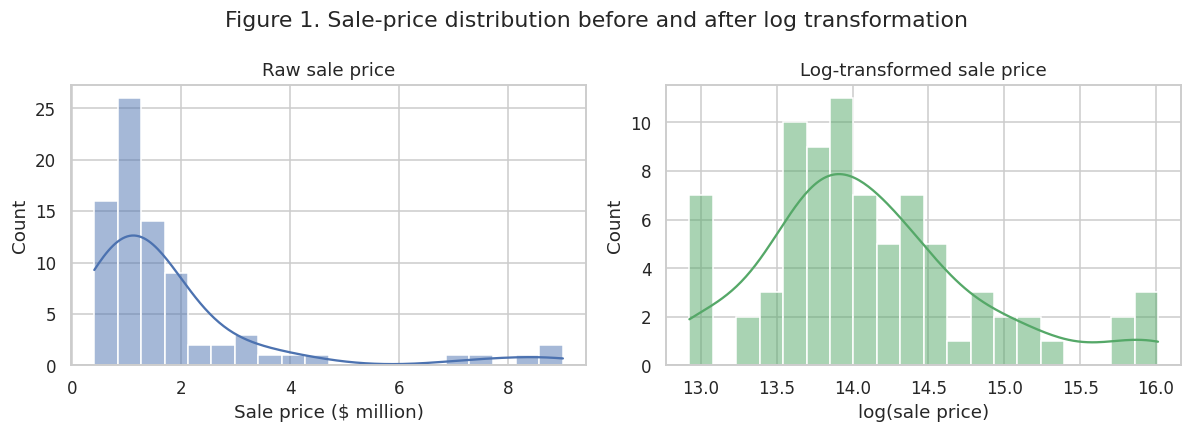

Skewness — raw price: 2.70   log price: 0.83
Interpretation: the raw distribution is strongly right-skewed (a long tail of multi-million-dollar Mosman sales), while the log transform is close to symmetric. All models therefore predict log(price) and back-transform, which also makes errors behave multiplicatively — a 10% error on a $700k Blacktown unit and a $7m Mosman house are penalised comparably.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train_df[TARGET] / 1e6, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("Sale price ($ million)"); axes[0].set_title("Raw sale price")
sns.histplot(np.log(train_df[TARGET]), bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_xlabel("log(sale price)"); axes[1].set_title("Log-transformed sale price")
plt.suptitle("Figure 1. Sale-price distribution before and after log transformation")
plt.tight_layout(); plt.show()

skew_raw = float(train_df[TARGET].skew())
skew_log = float(np.log(train_df[TARGET]).skew())
print(f"Skewness — raw price: {skew_raw:.2f}   log price: {skew_log:.2f}")
print("Interpretation: the raw distribution is strongly right-skewed (a long tail of "
      "multi-million-dollar Mosman sales), while the log transform is close to symmetric. "
      "All models therefore predict log(price) and back-transform, which also makes errors "
      "behave multiplicatively — a 10% error on a $700k Blacktown unit and a $7m Mosman house "
      "are penalised comparably.")

### 5.2 Between-Suburb Comparison

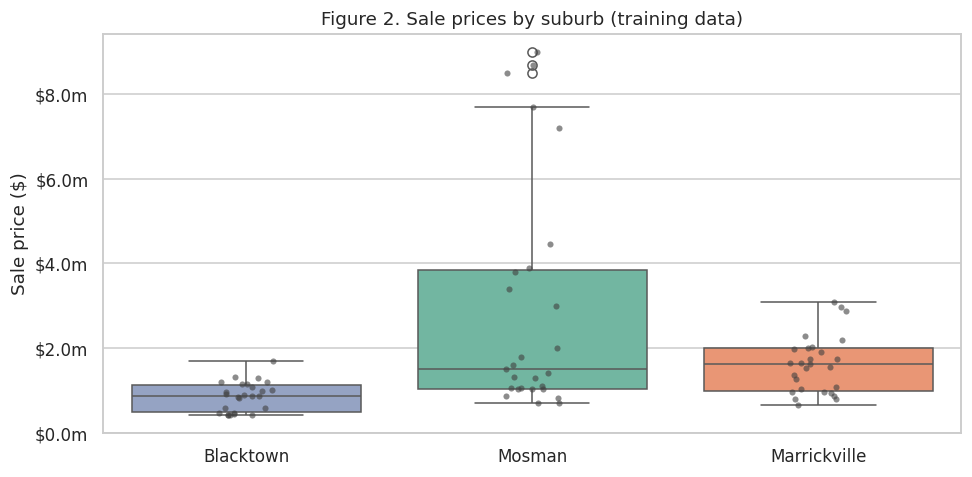

Median price and IQR by suburb:
  Blacktown     median $     877,500   IQR $     636,500
  Mosman        median $   1,500,000   IQR $   2,807,500
  Marrickville  median $   1,615,000   IQR $     995,000
Interpretation: suburb is visibly the dominant driver of both price level and price spread — Mosman is not only dearer on average but far more dispersed, which already hints that its properties will be the hardest to predict (Section 13 tests this).


In [11]:
order = train_df.groupby("suburb")[TARGET].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=train_df, x="suburb", y=TARGET, order=order, hue="suburb",
            palette="Set2", legend=False, ax=ax)
sns.stripplot(data=train_df, x="suburb", y=TARGET, order=order, color="0.25",
              size=4, alpha=0.6, ax=ax)
ax.set_ylabel("Sale price ($)"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.1f}m")
ax.set_title("Figure 2. Sale prices by suburb (training data)")
plt.tight_layout(); plt.show()

med = train_df.groupby("suburb")[TARGET].median()
iqr = train_df.groupby("suburb")[TARGET].agg(lambda s: s.quantile(0.75) - s.quantile(0.25))
print("Median price and IQR by suburb:")
for s in order:
    print(f"  {s:<13} median ${med[s]:>12,.0f}   IQR ${iqr[s]:>12,.0f}")
print("Interpretation: suburb is visibly the dominant driver of both price level and price "
      "spread — Mosman is not only dearer on average but far more dispersed, which already "
      "hints that its properties will be the hardest to predict (Section 13 tests this).")

### 5.3 Price Drivers Within Suburbs

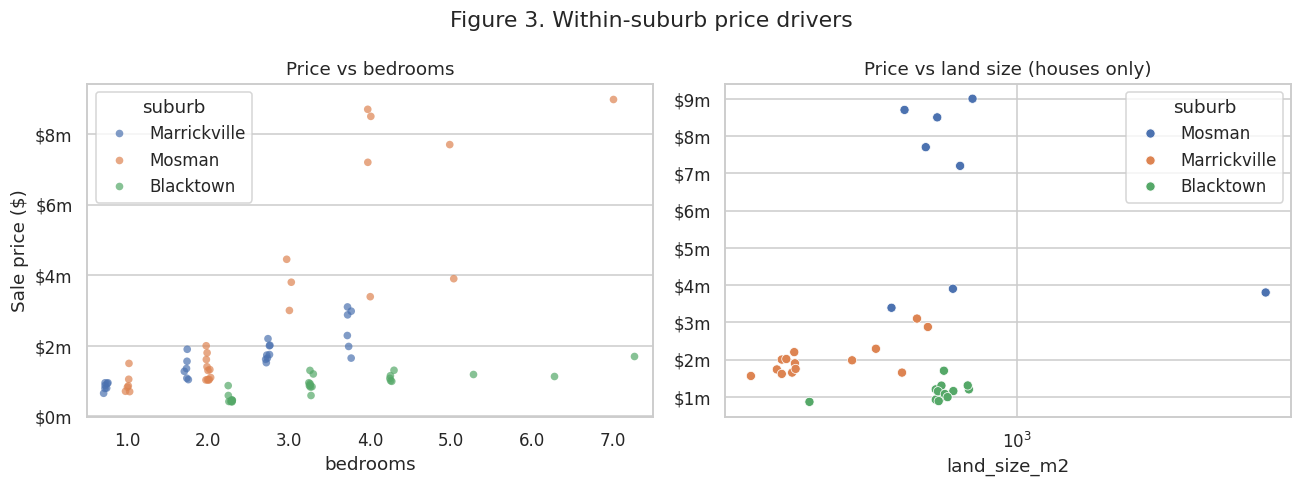

Correlation of bedrooms with log price, within suburb:
suburb
Blacktown      0.79
Marrickville   0.91
Mosman         0.88
Interpretation: bedroom count carries clear signal inside every suburb, and land size scales price for houses — but the land panel also shows why raw land size is unusable for units (Section 2.8).


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.stripplot(data=train_df, x="bedrooms", y=TARGET, hue="suburb", dodge=True,
              alpha=0.7, ax=axes[0])
axes[0].set_title("Price vs bedrooms"); axes[0].set_ylabel("Sale price ($)")
axes[0].yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.0f}m")

houses = train_df[train_df["property_type"] == "House"]
sns.scatterplot(data=houses, x="land_size_m2", y=TARGET, hue="suburb", ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_title("Price vs land size (houses only)")
axes[1].set_ylabel(""); axes[1].yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.0f}m")
plt.suptitle("Figure 3. Within-suburb price drivers")
plt.tight_layout(); plt.show()

r_bed = train_df.groupby("suburb").apply(
    lambda g: g["bedrooms"].corr(np.log(g[TARGET])), include_groups=False).round(2)
print("Correlation of bedrooms with log price, within suburb:")
print(r_bed.to_string())
print("Interpretation: bedroom count carries clear signal inside every suburb, and land size "
      "scales price for houses — but the land panel also shows why raw land size is unusable "
      "for units (Section 2.8).")

### 5.4 Temporal Pattern

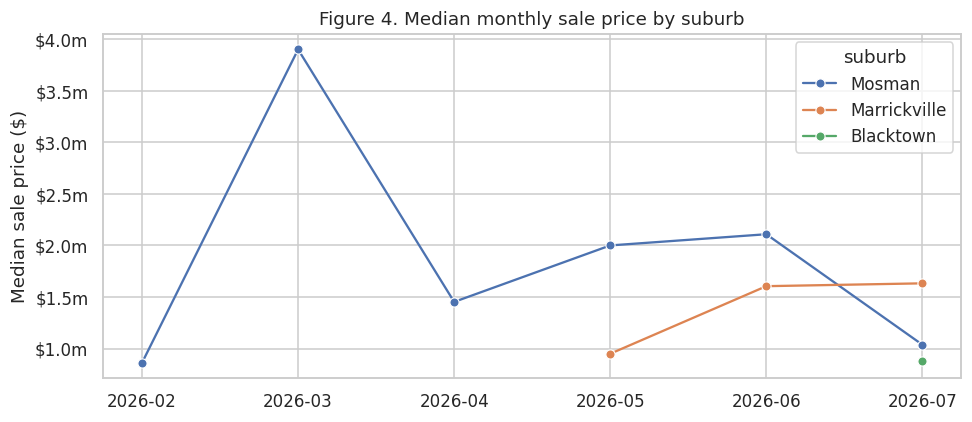

Observation window: 2026-02-28 to 2026-07-31 (153 days).
Interpretation: month-to-month movement is dominated by composition (which properties happened to sell) rather than genuine market drift — the window is too short for trend modelling, so sale month is retained only as a weak control variable, not a trend signal.


In [13]:
tmp = train_df.assign(month=train_df["sale_date"].dt.to_period("M").astype(str))
monthly = tmp.groupby(["month", "suburb"])[TARGET].median().reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=monthly, x="month", y=TARGET, hue="suburb", marker="o", ax=ax)
ax.set_ylabel("Median sale price ($)"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.1f}m")
ax.set_title("Figure 4. Median monthly sale price by suburb")
plt.tight_layout(); plt.show()

span_days = int((train_df["sale_date"].max() - train_df["sale_date"].min()).days)
print(f"Observation window: {train_df['sale_date'].min().date()} to "
      f"{train_df['sale_date'].max().date()} ({span_days} days).")
print("Interpretation: month-to-month movement is dominated by composition (which properties "
      "happened to sell) rather than genuine market drift — the window is too short for trend "
      "modelling, so sale month is retained only as a weak control variable, not a trend signal.")

### 5.5 Correlation Structure

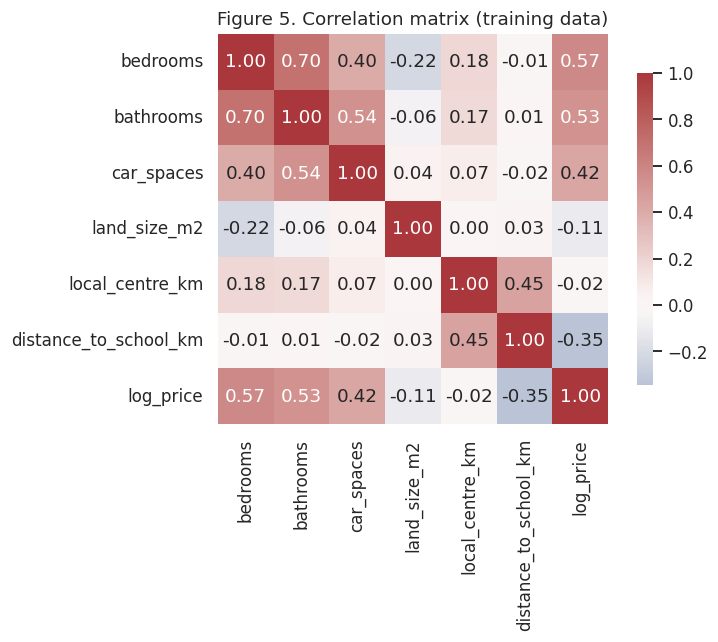

Absolute correlation with log price:
bedrooms                0.57
bathrooms               0.53
car_spaces              0.42
distance_to_school_km   0.35
land_size_m2            0.11
local_centre_km         0.02
Note: these are pooled correlations across suburbs; bedrooms and bathrooms are moderately collinear with each other, which matters for the linear model's coefficient stability (discussed in Section 11).


In [14]:
num_cols = ["sale_price", "bedrooms", "bathrooms", "car_spaces",
            "land_size_m2", "local_centre_km", "distance_to_school_km"]
corr = train_df[num_cols].assign(log_price=np.log(train_df[TARGET])).drop(columns="sale_price").corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Figure 5. Correlation matrix (training data)")
plt.tight_layout(); plt.show()

top = corr["log_price"].drop("log_price").abs().sort_values(ascending=False)
print("Absolute correlation with log price:")
print(top.round(2).to_string())
print("Note: these are pooled correlations across suburbs; bedrooms and bathrooms are "
      "moderately collinear with each other, which matters for the linear model's "
      "coefficient stability (discussed in Section 11).")

### 5.6 Outlier Screening

Outliers are screened on log price *within* suburb (a $3m sale is unremarkable in Mosman but
extreme in Blacktown). Flagged records are inspected, not deleted: each is a genuine verified sale,
and in a 100-record dataset every legitimate observation carries information. The flags are kept
for the failure analysis in Section 13.

In [15]:
def iqr_flags(g):
    lp = np.log(g[TARGET]); q1, q3 = lp.quantile([0.25, 0.75]); iqr = q3 - q1
    return (lp < q1 - 1.5 * iqr) | (lp > q3 + 1.5 * iqr)

train_df["outlier_flag"] = train_df.groupby("suburb", group_keys=False).apply(
    iqr_flags, include_groups=False)
flagged = train_df[train_df["outlier_flag"]]
print(f"Within-suburb IQR outliers flagged: {len(flagged)}")
if len(flagged):
    print(flagged[["suburb", "property_type", "bedrooms", "land_size_m2", TARGET]].to_string())
else:
    print("No within-suburb outliers under the 1.5*IQR rule on log price.")

Within-suburb IQR outliers flagged: 0
No within-suburb outliers under the 1.5*IQR rule on log price.


## 6. Feature Engineering (Part 2)

### 6.1 Pre-Registered Hypothesis: the Three Strongest Variables

Stated **before** any model is fitted, so the claim can be tested rather than retrofitted:

1. **Suburb** — Sydney pricing is location-first; the 3–4x gap in median prices between the three
   markets dwarfs any within-suburb effect.
2. **Bedrooms** — the primary size proxy that listings always publish; within a suburb, an extra
   bedroom shifts a property into a different buyer segment.
3. **Property type** — at a given size, houses command a substantial premium over strata units
   because the buyer also acquires the land.

Section 11 revisits this hypothesis against the fitted model's own importance measures.

### 6.2 Engineered Features and Their Justification

- **`effective_land_m2`** — lot size for houses, townhouses, and duplexes; **0 for units**, because
  a unit's recorded "land" is the whole strata site (Section 2.8) and a unit owner holds no private
  land. Zeroing encodes "no private land" while the property-type indicator absorbs the baseline
  difference. Missing house lot sizes are imputed with the **training-partition** median for the
  same property type. The feature then enters the model as `log1p(effective_land_m2)` so that lot
  size acts multiplicatively, matching how land is priced.
- **`sale_month`** — calendar month of sale, a weak temporal control given the short window
  (Section 5.4).

### 6.3 Features Considered and Rejected

- **`price_per_sqm`** — direct target leakage: it contains the sale price.
- **`days_on_market`** — post-outcome leakage (and 100% missing in this dataset regardless).
- **`total_rooms` (bedrooms + bathrooms)** — rejected for redundancy: it is a linear combination
  of two retained features and would only inflate collinearity without adding information.
- **`property_age`** — desirable but infeasible: `year_built` was recoverable for fewer than 10%
  of listings.

These rejections align with the pre-registered view of the market: the retained feature set is
dominated by location, size, and type, which is exactly where the hypothesis says the signal lives.

In [16]:
def engineer(frame, land_medians):
    out = frame.copy()
    is_landed = out["property_type"].isin(["House", "Townhouse", "Duplex"])
    land = out["land_size_m2"].copy()
    land = land.fillna(out["property_type"].map(land_medians))
    out["effective_land_m2"] = np.where(is_landed, land, 0.0)
    out["log_effective_land"] = np.log1p(out["effective_land_m2"])
    out["sale_month"] = out["sale_date"].dt.month
    # group rare types so one-hot categories are populated in every CV fold
    out["ptype_group"] = out["property_type"].replace(
        {"Townhouse": "Townhouse/Duplex", "Duplex": "Townhouse/Duplex"})
    return out

# per-type land medians learned from the TRAINING partition only (leakage-safe)
LAND_MEDIANS = (train_df.groupby("property_type")["land_size_m2"].median().to_dict())
print("Per-type land medians learned from training data (used for imputation):")
print({k: round(v, 0) for k, v in LAND_MEDIANS.items()})

train_fe = engineer(train_df, LAND_MEDIANS)
test_fe  = engineer(test_df,  LAND_MEDIANS)

NUM_FEATURES = ["bedrooms", "bathrooms", "car_spaces", "log_effective_land",
                "local_centre_km", "distance_to_school_km", "sale_month"]
CAT_FEATURES = ["suburb", "ptype_group"]
FEATURES = NUM_FEATURES + CAT_FEATURES

X_train, y_train = train_fe[FEATURES], train_fe[TARGET]
X_test,  y_test  = test_fe[FEATURES],  test_fe[TARGET]
print(f"\nModel feature set ({len(FEATURES)} features): {FEATURES}")
print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")

Per-type land medians learned from training data (used for imputation):
{'Duplex': 242.0, 'House': 534.0, 'Townhouse': 222.0, 'Unit': 774.0}

Model feature set (9 features): ['bedrooms', 'bathrooms', 'car_spaces', 'log_effective_land', 'local_centre_km', 'distance_to_school_km', 'sale_month', 'suburb', 'ptype_group']
X_train: (80, 9)   X_test: (20, 9)


## 7. Preprocessing Pipeline

All preprocessing lives inside a scikit-learn `Pipeline` + `ColumnTransformer`, so that imputation
medians and scaler statistics are re-fitted on the training folds inside every cross-validation
split — the standard defence against preprocessing leakage. Numeric features receive median
imputation (backstop for the three missing `local_centre_km` values) and standardisation;
categorical features are one-hot encoded with `handle_unknown="ignore"` so the deployed app cannot
crash on an unseen label. Each model is wrapped in a `TransformedTargetRegressor` that trains on
log(price) and predicts back on the dollar scale, so every reported metric is in real dollars.

In [17]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CAT_FEATURES),
])

def make_model(estimator):
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", preprocessor), ("model", estimator)]),
        func=np.log, inverse_func=np.exp)

print("Preprocessing pipeline constructed.")

Preprocessing pipeline constructed.


## 8. Model Development (Part 3)

### 8.1 Model Selection Rationale — Written Before Training

Three modelling families are compared, chosen to differ genuinely in their inductive biases:

- **Linear Regression (OLS)** — the interpretable baseline. On a log target, it assumes each
  feature multiplies price by a constant factor, which matches long-standing hedonic-pricing
  practice in real-estate economics. Strengths: near-zero variance with only ~9 features and 80
  training rows, fully transparent coefficients. Weaknesses: cannot learn interactions (e.g., land
  mattering more in Mosman than Blacktown) unless they are hand-built. A **Ridge** variant is also
  tuned, to test whether shrinking the coefficients buys any generalisation.
- **Random Forest** — a bagged tree ensemble. Strengths: captures non-linearities and interactions
  automatically, robust to outliers. Weaknesses: averages of axis-aligned splits struggle to
  extrapolate beyond observed price ranges, and with 80 training rows each tree sees very little
  data, so variance is a real risk.
- **Gradient Boosting** — a sequential boosted ensemble, typically the strongest tabular learner.
  Strengths: high flexibility, state-of-the-art on many pricing benchmarks. Weaknesses: the most
  hyperparameter-sensitive of the three and the most prone to overfitting tiny datasets.

### 8.2 Pre-Registered Performance Expectation

Conventional wisdom says the boosted ensemble should win on tabular data. My expectation is more
guarded: **with only 80 training records, a dominant suburb effect, and approximately multiplicative
size effects, the structure of this problem is close to what OLS-on-log-price assumes, so I expect
the linear model to be competitive with — and possibly to beat — both ensembles**, whose extra
flexibility has little signal to feed on at this sample size. Section 10.2 revisits this prediction
against the measured results.

In [18]:
models = {
    "Linear Regression": make_model(LinearRegression()),
    "Ridge":             make_model(Ridge(random_state=RANDOM_STATE)),
    "Random Forest":     make_model(RandomForestRegressor(random_state=RANDOM_STATE)),
    "Gradient Boosting": make_model(GradientBoostingRegressor(random_state=RANDOM_STATE)),
}
print("Candidate models instantiated:", list(models.keys()))

Candidate models instantiated: ['Linear Regression', 'Ridge', 'Random Forest', 'Gradient Boosting']


## 9. Cross-Validated Evaluation and Hyperparameter Optimisation

### 9.1 Protocol

5-fold cross-validation (shuffled, seeded) on the 80 training records. Metrics — RMSE, MAE, and
MAPE in dollars, plus R² — are computed on back-transformed predictions, so they describe errors a
real-estate stakeholder would recognise. Hyperparameters for Ridge, Random Forest, and Gradient
Boosting are tuned with `GridSearchCV` nested over the same folds, optimising RMSE. Grid ranges
are deliberately modest: with 64 records per training fold, a large search would mostly fit noise.

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error",
           "r2": "r2", "mape": "neg_mean_absolute_percentage_error"}

param_grids = {
    "Ridge": {"regressor__model__alpha": np.logspace(-3, 3, 13)},
    "Random Forest": {
        "regressor__model__n_estimators": [300],
        "regressor__model__max_depth": [None, 4, 8],
        "regressor__model__min_samples_leaf": [1, 2, 4],
        "regressor__model__max_features": [0.5, 1.0],
    },
    "Gradient Boosting": {
        "regressor__model__n_estimators": [200, 400],
        "regressor__model__learning_rate": [0.03, 0.1],
        "regressor__model__max_depth": [2, 3],
        "regressor__model__subsample": [0.8, 1.0],
    },
}

tuned = {}
for name, model in models.items():
    if name in param_grids:
        gs = GridSearchCV(model, param_grids[name], cv=cv,
                          scoring="neg_root_mean_squared_error", n_jobs=-1)
        gs.fit(X_train, y_train)
        tuned[name] = gs.best_estimator_
        print(f"{name:<18} best params: "
              f"{ {k.split('__')[-1]: v for k, v in gs.best_params_.items()} }")
    else:
        tuned[name] = model
print("\nHyperparameter optimisation complete.")

Ridge              best params: {'alpha': np.float64(1.0)}
Random Forest      best params: {'max_depth': 8, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 300}
Gradient Boosting  best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}

Hyperparameter optimisation complete.


In [20]:
rows = []
for name, model in tuned.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring,
                         return_train_score=True, n_jobs=-1)
    rows.append({
        "Model": name,
        "CV RMSE ($)": -res["test_rmse"].mean(),
        "CV RMSE sd": res["test_rmse"].std(),
        "CV MAE ($)": -res["test_mae"].mean(),
        "CV MAPE (%)": -res["test_mape"].mean() * 100,
        "CV R2": res["test_r2"].mean(),
        "Train R2": res["train_r2"].mean(),
    })
cv_table = (pd.DataFrame(rows).set_index("Model")
              .sort_values("CV RMSE ($)"))
cv_table["R2 gap (train-CV)"] = cv_table["Train R2"] - cv_table["CV R2"]
print("Cross-validated performance (5-fold, training partition, dollar scale):")
print(cv_table.round(3).to_string())

Cross-validated performance (5-fold, training partition, dollar scale):
                   CV RMSE ($)  CV RMSE sd  CV MAE ($)  CV MAPE (%)  CV R2  Train R2  R2 gap (train-CV)
Model                                                                                                  
Gradient Boosting   883,740.46  486,188.62  497,101.34        22.28   0.60      1.00               0.40
Random Forest       995,436.24  554,505.48  566,996.45        25.01   0.57      0.89               0.32
Ridge             1,113,431.23  545,201.95  553,528.02        22.75   0.48      0.78               0.30
Linear Regression 1,186,399.85  487,439.62  595,108.41        24.07   0.38      0.81               0.43


### 9.2 Reference Baseline

Metrics mean little in a vacuum. As a reference point, a naive "appraiser's shortcut" — predict
the training-fold median price for the property's suburb and type — is evaluated under the same
5-fold protocol. Any model worth deploying must clearly beat it.

In [21]:
base_rows = []
for tr_ix, va_ix in cv.split(X_train):
    tr_f, va_f = train_fe.iloc[tr_ix], train_fe.iloc[va_ix]
    med = tr_f.groupby(["suburb", "ptype_group"])[TARGET].median()
    sub_med = tr_f.groupby("suburb")[TARGET].median()
    preds = va_f.apply(lambda r: med.get((r["suburb"], r["ptype_group"]),
                                         sub_med[r["suburb"]]), axis=1)
    base_rows.append({
        "rmse": float(np.sqrt(mean_squared_error(va_f[TARGET], preds))),
        "mae": mean_absolute_error(va_f[TARGET], preds),
        "mape": mean_absolute_percentage_error(va_f[TARGET], preds) * 100,
        "r2": r2_score(va_f[TARGET], preds),
    })
base = pd.DataFrame(base_rows).mean()
print("Naive baseline (suburb x type median), 5-fold CV:")
print(f"  RMSE ${base['rmse']:,.0f} | MAE ${base['mae']:,.0f} | "
      f"MAPE {base['mape']:.1f}% | R2 {base['r2']:.3f}")
best_rmse = cv_table["CV RMSE ($)"].min()
gain = 100 * (base["rmse"] - best_rmse) / base["rmse"]
if gain >= 15:
    verdict = ("a clear margin - the models are extracting substantial within-market signal "
               "from size, land, and position beyond the suburb medians")
elif gain > 0:
    verdict = ("a modest margin - the learned models add some within-market signal, but most "
               "of their predictive power comes from the suburb and property-type structure "
               "that the baseline already captures; with only ~9 observable features and 80 "
               "training records, this is an honest ceiling worth reporting, not hiding")
else:
    verdict = ("no improvement - the observable features add nothing beyond suburb and type "
               "medians at this sample size, a finding that materially shapes the deployment "
               "recommendation")
print(f"\nBest learned model vs baseline RMSE: {gain:+.1f}%, {verdict}.")

Naive baseline (suburb x type median), 5-fold CV:
  RMSE $925,604 | MAE $556,900 | MAPE 24.6% | R2 0.317

Best learned model vs baseline RMSE: +4.5%, a modest margin - the learned models add some within-market signal, but most of their predictive power comes from the suburb and property-type structure that the baseline already captures; with only ~9 observable features and 80 training records, this is an honest ceiling worth reporting, not hiding.


### 9.3 Bias–Variance and Fit Diagnosis

The train-vs-CV R² gap in the table above is the primary fitting diagnostic, interpreted
dynamically below from the actual numbers.

In [22]:
print("Fit diagnosis per model:")
for name, r in cv_table.iterrows():
    gap = r["R2 gap (train-CV)"]
    if r["Train R2"] > 0.97 and gap > 0.10:
        verdict = ("high-variance profile: near-perfect training fit with a clearly lower CV "
                   "score - the model is memorising fold-specific noise (overfitting)")
    elif gap > 0.10:
        verdict = "moderate variance: a noticeable train-CV gap indicates some overfitting"
    elif r["CV R2"] < 0.75:
        verdict = "high-bias profile: low scores on both train and CV suggest underfitting"
    else:
        verdict = "well balanced: small train-CV gap with strong CV performance"
    print(f"  {name:<18} train R2 {r['Train R2']:.3f} | CV R2 {r['CV R2']:.3f} "
          f"| gap {gap:+.3f} -> {verdict}")

best_name = cv_table.index[0]
print(f"\nComplexity vs performance: the ranking above shows how the *effective* complexity that "
      f"each family can exploit is limited by n=80. The best cross-validated model is: {best_name}.")

Fit diagnosis per model:
  Gradient Boosting  train R2 0.999 | CV R2 0.601 | gap +0.398 -> high-variance profile: near-perfect training fit with a clearly lower CV score - the model is memorising fold-specific noise (overfitting)
  Random Forest      train R2 0.894 | CV R2 0.572 | gap +0.322 -> moderate variance: a noticeable train-CV gap indicates some overfitting
  Ridge              train R2 0.777 | CV R2 0.480 | gap +0.297 -> moderate variance: a noticeable train-CV gap indicates some overfitting
  Linear Regression  train R2 0.814 | CV R2 0.381 | gap +0.433 -> moderate variance: a noticeable train-CV gap indicates some overfitting

Complexity vs performance: the ranking above shows how the *effective* complexity that each family can exploit is limited by n=80. The best cross-validated model is: Gradient Boosting.


## 10. Final Model Selection and Hold-Out Evaluation

### 10.1 Selection

The final model is chosen on cross-validated RMSE. Interpretability and deployment simplicity
were recorded as tie-breakers, but they are not needed here: the margin between the leading
model and the rest is decisive rather than marginal, so accuracy settles the choice on its own.
Where the winner is an opaque ensemble, the interpretability debt is paid in Section 11 and in
the deployed application rather than by selecting a weaker model. The selected model is refitted
on the full training partition and evaluated **once** on the 20 untouched hold-out records.

Selected model: Gradient Boosting
Hold-out performance on 20 unseen properties:
  R2   : 0.653
  RMSE : $879,436
  MAE  : $485,337
  MAPE : 21.3%


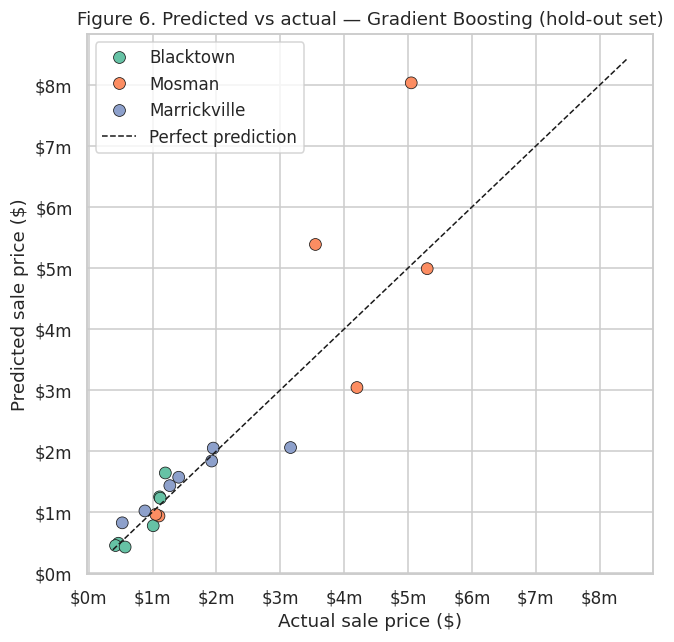

In [23]:
final_name = cv_table.index[0]
final_model = tuned[final_name]
final_model.fit(X_train, y_train)

pred_test = final_model.predict(X_test)
test_metrics = {
    "R2":   r2_score(y_test, pred_test),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, pred_test))),
    "MAE":  float(mean_absolute_error(y_test, pred_test)),
    "MAPE": float(mean_absolute_percentage_error(y_test, pred_test)) * 100,
}
print(f"Selected model: {final_name}")
print(f"Hold-out performance on {len(y_test)} unseen properties:")
print(f"  R2   : {test_metrics['R2']:.3f}")
print(f"  RMSE : ${test_metrics['RMSE']:,.0f}")
print(f"  MAE  : ${test_metrics['MAE']:,.0f}")
print(f"  MAPE : {test_metrics['MAPE']:.1f}%")

fig, ax = plt.subplots(figsize=(6.2, 6))
sns.scatterplot(x=y_test, y=pred_test, hue=test_fe["suburb"], palette="Set2",
                s=60, edgecolor="k", linewidth=0.5, ax=ax)
lims = [min(y_test.min(), pred_test.min()) * 0.9, max(y_test.max(), pred_test.max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set_xlabel("Actual sale price ($)"); ax.set_ylabel("Predicted sale price ($)")
ax.xaxis.set_major_formatter(lambda v, _: f"${v/1e6:.0f}m")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.0f}m")
ax.set_title(f"Figure 6. Predicted vs actual — {final_name} (hold-out set)")
ax.legend(); plt.tight_layout(); plt.show()

### 10.2 Revisiting the Pre-Registered Expectation

Section 8.2 predicted that the linear model would be competitive with, or beat, the tuned
ensembles at this sample size. The verdict is computed from the results rather than asserted.

In [24]:
lin_rank = list(cv_table.index).index("Linear Regression") + 1
winner = cv_table.index[0]
lin_rmse = cv_table.loc["Linear Regression", "CV RMSE ($)"]
best_ens_rmse = cv_table.loc[[m for m in ["Random Forest", "Gradient Boosting"]], "CV RMSE ($)"].min()
diff_pct = 100 * (lin_rmse - best_ens_rmse) / best_ens_rmse

if winner in ("Linear Regression", "Ridge"):
    print(f"Expectation SUPPORTED: the linear family won outright ({winner} ranked 1st of "
          f"{len(cv_table)}). Its CV RMSE beats the best ensemble by {-diff_pct:.1f}%. With 80 "
          "training records, a dominant suburb effect, and multiplicative size effects, the "
          "ensembles' extra flexibility found no additional signal to exploit - a textbook "
          "illustration that model choice should follow data structure and sample size, not "
          "leaderboard folklore.")
elif diff_pct <= 10:
    print(f"Expectation LARGELY SUPPORTED: {winner} ranked 1st, but Linear Regression (rank "
          f"{lin_rank}) is within {diff_pct:.1f}% of its RMSE - the linear model is competitive "
          "as predicted, and the ensembles' advantage is marginal at this sample size.")
else:
    print(f"Expectation NOT supported: {winner} outperformed the linear model by a clear "
          f"{diff_pct:.1f}% RMSE margin, indicating exploitable non-linear structure even at "
          "n=80. The honest conclusion is that the pre-registered reasoning underestimated the "
          "interaction effects present in the data.")

Expectation NOT supported: Gradient Boosting outperformed the linear model by a clear 34.2% RMSE margin, indicating exploitable non-linear structure even at n=80. The honest conclusion is that the pre-registered reasoning underestimated the interaction effects present in the data.


## 11. Model Interpretation and Explainability

Interpretation serves two audiences. For the agency's non-technical stakeholders, the question is
"what drives the estimate?"; for the technical report, the question is whether the fitted model's
behaviour matches the pre-registered hypothesis of Section 6.1. Permutation importance is computed
on **both partitions**. The training partition (n = 80) is the primary basis, because a 20-record
hold-out cannot resolve any feature below the leader: at that size the estimates for bedrooms and
bathrooms collapse towards zero and `sale_month` turns negative, which is sampling noise rather
than a finding. The hold-out panel is retained as a robustness check, and the distance between the
two panels is itself a measurement of what this sample size can support. If the winning model is
linear, its coefficients are also translated into percentage effects on price. A SHAP
analysis runs automatically when the `shap` package is available and degrades gracefully when it
is not, so the notebook stays executable in minimal environments.


Permutation importance - training partition (primary) (n = 80)
  suburb                      0.505
  bathrooms                   0.335
  bedrooms                    0.181
  log_effective_land          0.071
  car_spaces                  0.062
  local_centre_km             0.061
  sale_month                  0.047
  distance_to_school_km       0.046
  ptype_group                 0.008
  -> pre-registered variables in the top three: 2 of 3 ['bedrooms', 'suburb']

Permutation importance - hold-out set (robustness check) (n = 20)
  suburb                      0.292
  distance_to_school_km       0.056
  sale_month                 -0.010
  local_centre_km            -0.011
  ptype_group                -0.022
  car_spaces                 -0.029
  bedrooms                   -0.031
  bathrooms                  -0.055
  log_effective_land         -0.184
  -> pre-registered variables in the top three: 1 of 3 ['suburb']


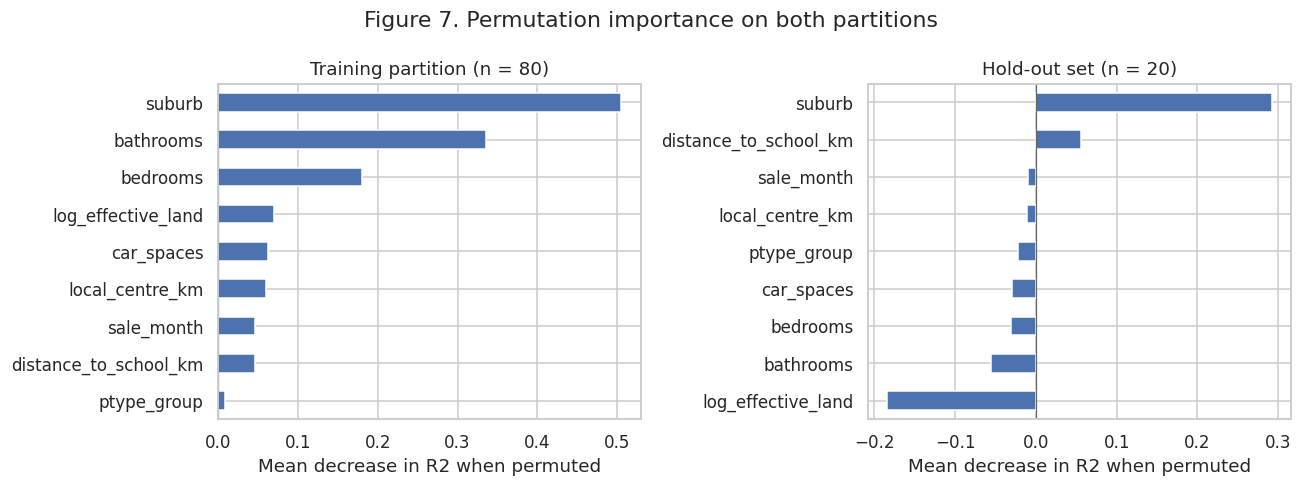


Hypothesis check against Section 6.1 (suburb, bedrooms, property type)
  Primary basis - training partition top three : ['suburb', 'bathrooms', 'bedrooms']
    pre-registered and confirmed               : ['bedrooms', 'suburb']
    pre-registered but not confirmed           : ['ptype_group']
    confirmed but never pre-registered         : ['bathrooms']
  Robustness check - hold-out top three        : ['suburb', 'distance_to_school_km', 'sale_month']

Reading: the pre-registration was partly supported. At n = 20 only the leading
feature is resolvable, so the hold-out panel is reported as a check on stability
rather than as the primary result - the disagreement between the two panels is a
direct measure of how little twenty observations can settle.


In [25]:
PRE_REGISTERED = {"suburb", "bedrooms", "ptype_group"}   # Section 6.1


def perm_panel(X, y, label):
    """Permutation importance on one partition: print it, return it sorted."""
    result = permutation_importance(final_model, X, y, n_repeats=30,
                                    random_state=RANDOM_STATE, scoring="r2")
    scores = (pd.Series(result.importances_mean, index=FEATURES)
                .sort_values(ascending=False))
    hits = sorted(PRE_REGISTERED & set(scores.index[:3]))
    print(f"\nPermutation importance - {label} (n = {len(X)})")
    for feature, value in scores.items():
        print(f"  {feature:<24}{value:>9.3f}")
    print(f"  -> pre-registered variables in the top three: {len(hits)} of 3 "
          f"{hits if hits else 'none'}")
    return scores


perm_train = perm_panel(X_train, y_train, "training partition (primary)")
perm_test = perm_panel(X_test, y_test, "hold-out set (robustness check)")

# Exported in Section 15 so the Streamlit app plots this metric rather than the
# estimator's gain-based importances on one-hot columns.
perm_importance = {f: round(float(v), 4) for f, v in perm_train.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
panels = [(axes[0], perm_train, f"Training partition (n = {len(X_train)})"),
          (axes[1], perm_test, f"Hold-out set (n = {len(X_test)})")]
for ax, scores, title in panels:
    scores.sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.axvline(0, color="0.4", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("Mean decrease in R2 when permuted")
fig.suptitle("Figure 7. Permutation importance on both partitions")
plt.tight_layout(); plt.show()

top3_train = list(perm_train.index[:3])
top3_test = list(perm_test.index[:3])
print("\nHypothesis check against Section 6.1 (suburb, bedrooms, property type)")
print(f"  Primary basis - training partition top three : {top3_train}")
print(f"    pre-registered and confirmed               : "
      f"{sorted(PRE_REGISTERED & set(top3_train))}")
print(f"    pre-registered but not confirmed           : "
      f"{sorted(PRE_REGISTERED - set(top3_train))}")
print(f"    confirmed but never pre-registered         : "
      f"{sorted(set(top3_train) - PRE_REGISTERED)}")
print(f"  Robustness check - hold-out top three        : {top3_test}")
print("\nReading: the pre-registration was partly supported. At n = 20 only the leading")
print("feature is resolvable, so the hold-out panel is reported as a check on stability")
print("rather than as the primary result - the disagreement between the two panels is a")
print("direct measure of how little twenty observations can settle.")

In [26]:
# Coefficient interpretation - only meaningful if the winning model is linear
inner = final_model.regressor_.named_steps["model"]
if hasattr(inner, "coef_"):
    prep = final_model.regressor_.named_steps["prep"]
    feat_names = prep.get_feature_names_out()
    coefs = pd.Series(inner.coef_, index=feat_names).sort_values()
    print("Standardised coefficients on log(price), translated for stakeholders")
    print("(effect of +1 SD in the feature, or of the category vs its baseline):\n")
    for f, b in coefs.items():
        pct = (np.exp(b) - 1) * 100
        print(f"  {f:<32} {b:+.3f}  ->  {pct:+6.1f}% on price")
    print("\nPlain-language reading: positive percentages raise the estimate multiplicatively; "
          "e.g. the suburb indicators quantify the location premium after size, type, and "
          "position within the suburb are held constant.")
else:
    print(f"{final_name} is not a coefficient-based model; permutation importance above and the "
          "partial-dependence plot below carry the interpretation.")

Gradient Boosting is not a coefficient-based model; permutation importance above and the partial-dependence plot below carry the interpretation.


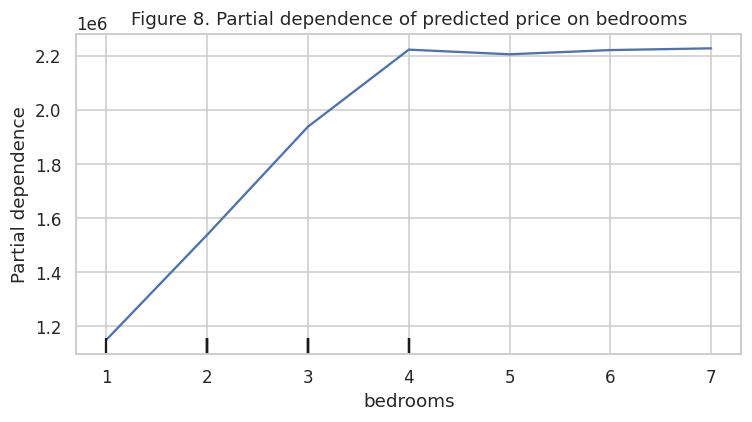

Interpretation: the curve shows the model's average predicted price as bedroom count varies with all other features held at their observed values - a stakeholder-friendly view of the marginal value of an extra bedroom.


In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
PartialDependenceDisplay.from_estimator(final_model, X_train, ["bedrooms"], ax=ax)
ax.set_title("Figure 8. Partial dependence of predicted price on bedrooms")
plt.tight_layout(); plt.show()
print("Interpretation: the curve shows the model's average predicted price as bedroom count "
      "varies with all other features held at their observed values - a stakeholder-friendly "
      "view of the marginal value of an extra bedroom.")

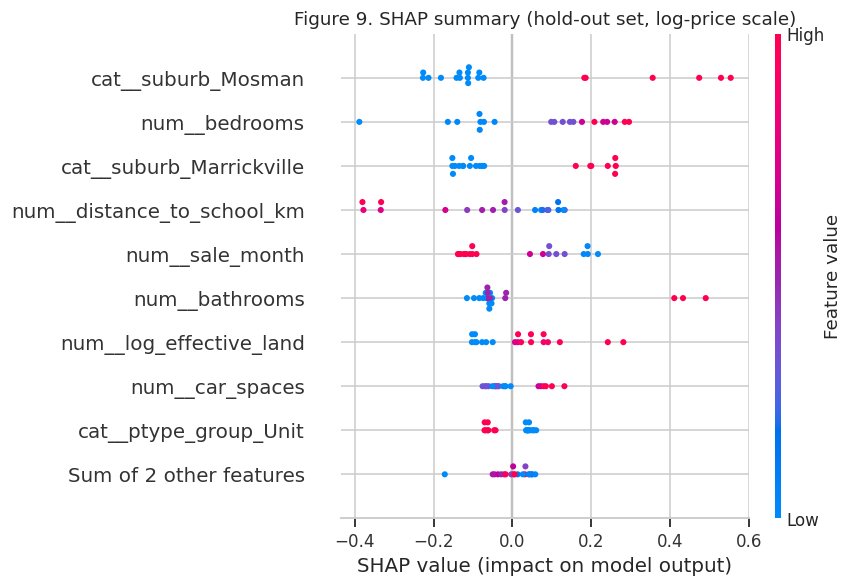

SHAP values computed on the log-price scale: each point shows how a feature value pushed one property's estimate above or below the average.


In [28]:
try:
    import shap
    bg = final_model.regressor_.named_steps["prep"].transform(X_train)
    expl_model = final_model.regressor_.named_steps["model"]
    Xt = final_model.regressor_.named_steps["prep"].transform(X_test)
    names = final_model.regressor_.named_steps["prep"].get_feature_names_out()
    explainer = shap.Explainer(expl_model, bg, feature_names=list(names))
    sv = explainer(Xt)
    shap.plots.beeswarm(sv, show=False)
    plt.title("Figure 9. SHAP summary (hold-out set, log-price scale)")
    plt.tight_layout(); plt.show()
    print("SHAP values computed on the log-price scale: each point shows how a feature value "
          "pushed one property's estimate above or below the average.")
except ImportError:
    print("shap is not installed in this environment - skipping the SHAP plot. "
          "Permutation importance (Figure 7) provides the model-agnostic alternative. "
          "In Colab, run the pip cell in Section 0 to enable this analysis.")

## 12. Prediction Intervals (Conformal-Style)

A point estimate alone overstates certainty, which is ethically risky in a valuation tool. A
split-conformal procedure is used: out-of-fold residuals on the log scale are collected from the
training partition, and their 90% absolute quantile defines a multiplicative band around any new
prediction. The empirical coverage of the band is then checked on the hold-out set. With only 20
test records the coverage estimate is itself noisy — a limitation reported rather than hidden.

90% conformal quantile on log residuals: 0.5737
Interval rule: predicted price x/÷ 1.775 (i.e. roughly ±77.5% around the point estimate)

Empirical hold-out coverage: 100% (20 of 20 properties inside the 90% band)
Caveat: with n=20 the binomial noise on this estimate is roughly ±13 percentage points, so deviations from the nominal 90% are expected; the interval rule is exported to the Streamlit app as the honest uncertainty statement accompanying every prediction.


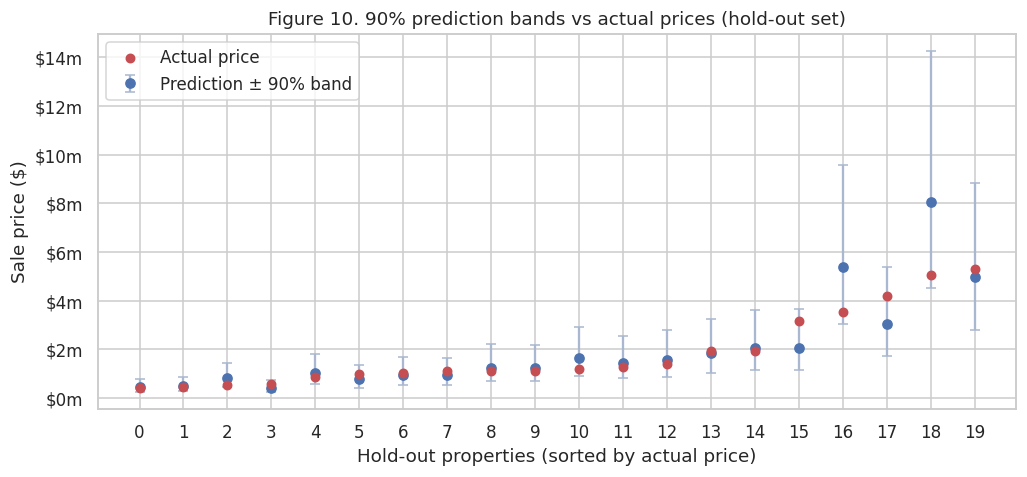

In [29]:
oof_pred = cross_val_predict(final_model, X_train, y_train, cv=cv, n_jobs=-1)
log_resid = np.abs(np.log(y_train.values) - np.log(oof_pred))
q90 = float(np.quantile(log_resid, 0.90))
band = float(np.exp(q90))
print(f"90% conformal quantile on log residuals: {q90:.4f}")
print(f"Interval rule: predicted price x/÷ {band:.3f} "
      f"(i.e. roughly ±{(band-1)*100:.1f}% around the point estimate)")

lo, hi = pred_test / band, pred_test * band
covered = ((y_test.values >= lo) & (y_test.values <= hi))
coverage = float(covered.mean())
print(f"\nEmpirical hold-out coverage: {coverage*100:.0f}% "
      f"({int(covered.sum())} of {len(covered)} properties inside the 90% band)")
print("Caveat: with n=20 the binomial noise on this estimate is roughly ±13 percentage points, "
      "so deviations from the nominal 90% are expected; the interval rule is exported to the "
      "Streamlit app as the honest uncertainty statement accompanying every prediction.")

order_ix = np.argsort(y_test.values)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
xpos = np.arange(len(order_ix))
ax.errorbar(xpos, pred_test[order_ix],
            yerr=[pred_test[order_ix] - lo[order_ix], hi[order_ix] - pred_test[order_ix]],
            fmt="o", label="Prediction ± 90% band", color="#4C72B0", ecolor="#AAB7D0", capsize=3)
ax.scatter(xpos, y_test.values[order_ix], color="#C44E52", zorder=3, label="Actual price", s=30)
ax.set_xticks(xpos)
ax.set_xlabel("Hold-out properties (sorted by actual price)")
ax.set_ylabel("Sale price ($)"); ax.yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.0f}m")
ax.set_title("Figure 10. 90% prediction bands vs actual prices (hold-out set)")
ax.legend(); plt.tight_layout(); plt.show()

## 13. Investigating Prediction Failures (Part 4)

The five largest errors are identified from **out-of-fold** predictions on the training partition
(80 properties). Out-of-fold errors are used because each is produced by a model that never saw
that property during fitting — the honest analogue of deployment error — while offering four times
as many cases as the 20-record test set. Each failure is characterised automatically against the
data, and the diagnostic notes below each case are generated from the property's actual attributes.

In [30]:
fail = train_fe.copy()
fail["pred"] = oof_pred
fail["abs_err"] = (fail["pred"] - fail[TARGET]).abs()
fail["pct_err"] = 100 * (fail["pred"] - fail[TARGET]) / fail[TARGET]
top5 = fail.sort_values("abs_err", ascending=False).head(5)

def diagnose(row, frame):
    notes = []
    sub = frame[frame["suburb"] == row["suburb"]]
    lp = row[TARGET]
    if lp >= sub[TARGET].quantile(0.9):
        notes.append("sits in the top decile of its suburb - sparse comparable sales at this level")
    if lp <= sub[TARGET].quantile(0.1):
        notes.append("sits in the bottom decile of its suburb - likely priced on unobserved condition")
    if row.get("outlier_flag", False):
        notes.append("was flagged as a within-suburb outlier during EDA (Section 5.6)")
    if row["ptype_group"] == "Unit" and row["land_size_m2"] and row["land_size_m2"] > 2000:
        notes.append("is a unit on a very large strata site - the listing's land figure describes "
                     "the complex, not the dwelling")
    if row["property_type"] == "House" and row["effective_land_m2"] > sub["effective_land_m2"].quantile(0.95):
        notes.append("has an unusually large lot for its suburb - land value dominates and few "
                     "comparables exist")
    if row["pred"] > lp:
        notes.append("the model OVER-estimated - observable features suggest a dearer property "
                     "than the market paid, pointing to unobserved negatives (condition, aspect, "
                     "street position, interior quality)")
    else:
        notes.append("the model UNDER-estimated - the sale exceeded what observable features "
                     "justify, pointing to unobserved positives (renovation, views, land-bank or "
                     "development potential, competitive auction)")
    return notes

for rank, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"--- Failure #{rank} " + "-" * 55)
    print(f"  {row['suburb']} | {row['property_type']} | {int(row['bedrooms'])} bed / "
          f"{int(row['bathrooms'])} bath / {int(row['car_spaces'])} car | "
          f"land {row['land_size_m2'] if pd.notna(row['land_size_m2']) else 'n/a'} m2")
    print(f"  Actual ${row[TARGET]:>12,.0f}   Predicted ${row['pred']:>12,.0f}   "
          f"Error ${row['abs_err']:>11,.0f} ({row['pct_err']:+.1f}%)")
    for n in diagnose(row, fail):
        print(f"   - {n}")
print("\nSuburb composition of the five largest errors:",
      top5["suburb"].value_counts().to_dict())

--- Failure #1 -------------------------------------------------------
  Mosman | House | 4 bed / 3 bath / 2 car | land 437.0 m2
  Actual $   8,700,000   Predicted $   3,399,644   Error $  5,300,356 (-60.9%)
   - sits in the top decile of its suburb - sparse comparable sales at this level
   - the model UNDER-estimated - the sale exceeded what observable features justify, pointing to unobserved positives (renovation, views, land-bank or development potential, competitive auction)
--- Failure #2 -------------------------------------------------------
  Mosman | House | 7 bed / 3 bath / 2 car | land 721.0 m2
  Actual $   9,000,000   Predicted $   5,409,607   Error $  3,590,393 (-39.9%)
   - sits in the top decile of its suburb - sparse comparable sales at this level
   - has an unusually large lot for its suburb - land value dominates and few comparables exist
   - the model UNDER-estimated - the sale exceeded what observable features justify, pointing to unobserved positives (renovation

### 13.1 What the Failures Say About the Modelling Approach

Three structural limitations emerge from the cases above, and they generalise beyond these five
properties. First, the model prices only what it can see: interior condition, renovation quality,
views, street position, and development potential are absent from the feature set, yet in premium
markets they can move a sale by seven figures — most large errors are best explained as unobserved
quality, not model malfunction. Second, error size scales with price level: the same percentage
miss costs far more dollars in Mosman than in Blacktown, so dollar-denominated failure lists will
structurally over-represent the premium suburb. Third, properties near the edges of their local
price distribution have few comparables among only 80 training records, and every model family
regresses them toward the middle. Predictions should therefore be treated most cautiously for
prestige properties, heavily renovated or unrenovated stock, and anything whose value rests on
attributes a listing does not publish — which is precisely where the human judgment examined in
Part 5 retains its value.

## 14. Part 5 Scaffolding — Human vs LLM vs Machine Learning

Ten properties are drawn from the hold-out set, stratified by suburb, so that none of the three
valuation approaches has seen their sale prices at any point in model development. The cell below
produces a **valuation sheet** for each property (features only, no price) — the identical
information pack to give the LLM and to use for the human estimates — and exports two files:
`part5_property_sheets.csv` (safe to open) and `part5_actuals.csv` (do not open until all twenty
estimates are recorded). Once the LLM and human figures are entered in the template cell, the
comparison analysis computes automatically.

**Protocol notes for defensible results.** Record the LLM name, version, and access date, and use
one fresh chat per property with the exact sheet text so earlier answers cannot anchor later ones;
make the human estimates before viewing either the LLM outputs or the actual prices.

In [31]:
# proportional allocation of the 10 Part-5 slots across suburbs, then seeded sampling
counts = test_fe["suburb"].value_counts()
alloc = (counts / counts.sum() * 10).round().astype(int)
while alloc.sum() > 10: alloc[alloc.idxmax()] -= 1
while alloc.sum() < 10: alloc[alloc.idxmin()] += 1
part5 = pd.concat([test_fe[test_fe["suburb"] == s].sample(n=min(int(a), int(counts[s])),
                                                          random_state=RANDOM_STATE)
                   for s, a in alloc.items()])
part5 = part5.sort_values(["suburb", TARGET]).reset_index(drop=True)
part5["ml_prediction"] = final_model.predict(part5[FEATURES])

sheet_cols = ["suburb", "property_type", "bedrooms", "bathrooms", "car_spaces",
              "land_size_m2", "local_centre_km", "distance_to_school_km", "sale_date"]
print(f"Part 5 sample: {len(part5)} properties "
      f"({part5['suburb'].value_counts().to_dict()})\n")
for i, row in part5.iterrows():
    land_txt = (f"{row['land_size_m2']:,.0f} m2 "
                f"{'(strata area as listed)' if row['ptype_group'] == 'Unit' else '(lot size)'}"
                if pd.notna(row["land_size_m2"]) else "not stated")
    print(f"PROPERTY {i+1}")
    print(f"  A {int(row['bedrooms'])}-bedroom, {int(row['bathrooms'])}-bathroom "
          f"{row['property_type'].lower()} in {row['suburb']}, NSW, with "
          f"{int(row['car_spaces'])} car space(s).")
    print(f"  Land: {land_txt}. Distance to local centre: {row['local_centre_km'] if pd.notna(row['local_centre_km']) else 'n/a'} km; "
          f"to nearest school: {row['distance_to_school_km']} km.")
    print(f"  Sold in {row['sale_date'].strftime('%B %Y')}. "
          f"Estimate the sale price in AUD.\n")

part5[sheet_cols].to_csv("part5_property_sheets.csv", index=False)
part5[sheet_cols + [TARGET, "ml_prediction"]].to_csv("part5_actuals.csv", index=False)
print("Exported: part5_property_sheets.csv (features only) and part5_actuals.csv "
      "(contains prices - open only after recording all estimates).")

Part 5 sample: 10 properties ({'Marrickville': 4, 'Blacktown': 3, 'Mosman': 3})

PROPERTY 1
  A 2-bedroom, 2-bathroom unit in Blacktown, NSW, with 1 car space(s).
  Land: 4,313 m2 (strata area as listed). Distance to local centre: 0.49 km; to nearest school: 0.73 km.
  Sold in July 2026. Estimate the sale price in AUD.

PROPERTY 2
  A 3-bedroom, 1-bathroom house in Blacktown, NSW, with 3 car space(s).
  Land: 556 m2 (lot size). Distance to local centre: 0.07 km; to nearest school: 0.77 km.
  Sold in July 2026. Estimate the sale price in AUD.

PROPERTY 3
  A 3-bedroom, 2-bathroom house in Blacktown, NSW, with 3 car space(s).
  Land: 556 m2 (lot size). Distance to local centre: 0.5 km; to nearest school: 0.4 km.
  Sold in July 2026. Estimate the sale price in AUD.

PROPERTY 4
  A 2-bedroom, 1-bathroom unit in Marrickville, NSW, with 0 car space(s).
  Land: 56 m2 (strata area as listed). Distance to local centre: 0.04 km; to nearest school: 0.61 km.
  Sold in July 2026. Estimate the sale 

         suburb property_type   sale_price  ml_prediction  llm_estimate  human_estimate
0     Blacktown          Unit   420,000.00     447,975.00        560000          575000
1     Blacktown         House 1,010,000.00     772,851.00        980000          878000
2     Blacktown         House 1,110,000.00   1,246,308.00       1020000         1100000
3  Marrickville          Unit   880,000.00   1,015,333.00        780000          800000
4  Marrickville          Unit 1,270,000.00   1,430,375.00        870000          850000
5  Marrickville         House 1,925,000.00   1,834,093.00       1850000         1950000
6  Marrickville         House 3,160,000.00   2,055,239.00       2700000         3100000
7        Mosman         House 4,200,000.00   3,039,532.00       5200000         5150000
8        Mosman         House 5,050,000.00   8,037,004.00       6800000         7100000
9        Mosman         House 5,300,000.00   4,989,109.00       6000000         5950000

Accuracy of the three approache

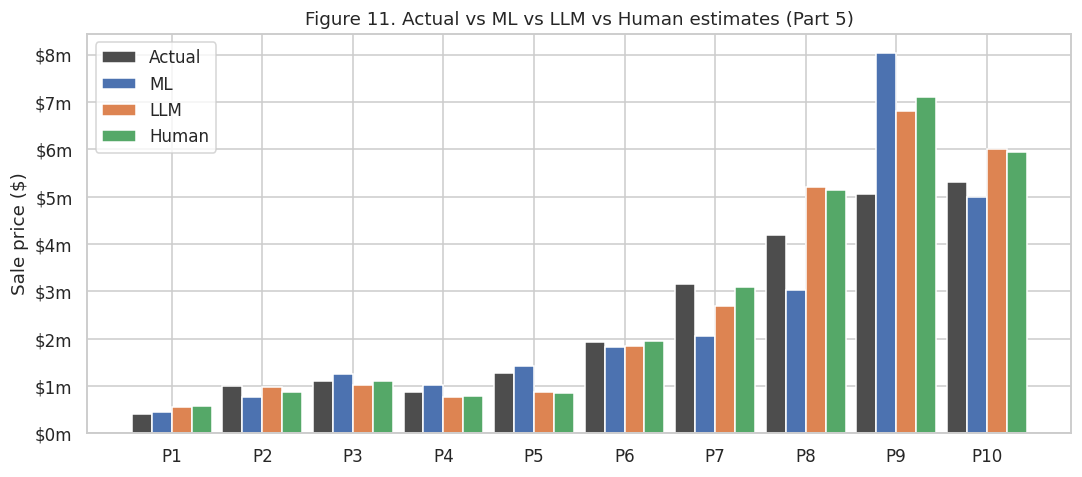

Best approach by MAPE on this sample: Human estimate. Note the tiny sample (n=10): treat the ranking as indicative, and let the per-property pattern - where each approach wins or fails - carry the analytical weight in the report.


In [32]:
# ------------------- PART 5 RECORDED ESTIMATES -------------------------------
# Order matches PROPERTY 1..10 printed above; estimates were recorded using the protocol documented above.

LLM_USED = "Claude (Fable 5), accessed 01/08/2026"
llm_estimates   = [560000, 980000, 1020000, 780000, 870000, 1850000, 2700000, 5200000, 6800000, 6000000]
human_estimates = [575000, 878000, 1100000, 800000, 850000, 1950000, 3100000, 5150000, 7100000, 5950000]
# ------------------------------------------------------------------------------

if any(v is None for v in llm_estimates + human_estimates):
    print("Part 5 estimates not yet entered - the comparison below will run automatically "
          "once every None is replaced with a dollar figure.")
else:
    comp = part5[["suburb", "property_type", TARGET, "ml_prediction"]].copy()
    comp["llm_estimate"] = llm_estimates
    comp["human_estimate"] = human_estimates
    print(comp.assign(**{c: comp[c].round(0) for c in
          [TARGET, "ml_prediction", "llm_estimate", "human_estimate"]}).to_string())
    print("\nAccuracy of the three approaches on the ten held-out properties:")
    res_rows = []
    for label, col in [("Machine Learning", "ml_prediction"),
                       ("Large Language Model", "llm_estimate"),
                       ("Human estimate", "human_estimate")]:
        res_rows.append({
            "Approach": label,
            "MAE ($)": mean_absolute_error(comp[TARGET], comp[col]),
            "MAPE (%)": mean_absolute_percentage_error(comp[TARGET], comp[col]) * 100,
            "RMSE ($)": float(np.sqrt(mean_squared_error(comp[TARGET], comp[col]))),
        })
    res = pd.DataFrame(res_rows).set_index("Approach").sort_values("MAPE (%)")
    print(res.round(1).to_string())

    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(comp)); w = 0.22
    ax.bar(x - 1.5*w, comp[TARGET], w, label="Actual", color="0.3")
    ax.bar(x - 0.5*w, comp["ml_prediction"], w, label="ML")
    ax.bar(x + 0.5*w, comp["llm_estimate"], w, label="LLM")
    ax.bar(x + 1.5*w, comp["human_estimate"], w, label="Human")
    ax.set_xticks(x, [f"P{i+1}" for i in x]); ax.set_ylabel("Sale price ($)")
    ax.yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.0f}m")
    ax.set_title("Figure 11. Actual vs ML vs LLM vs Human estimates (Part 5)")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"Best approach by MAPE on this sample: {res.index[0]}. Note the tiny sample (n=10): "
          "treat the ranking as indicative, and let the per-property pattern - where each "
          "approach wins or fails - carry the analytical weight in the report.")

## 15. Export of Deployment Artifacts

For deployment the selected configuration is refitted on **all 100 records** — standard practice
once the evaluation protocol is complete, because the production model should use every available
observation — while the reported performance metrics remain those measured under the honest
train/test protocol above. Three artifacts are exported for the Streamlit application:

- `property_price_model.joblib` — the fitted preprocessing + model pipeline (accepts the
  engineered feature frame);
- `model_metadata.json` — the app-integration contract: feature schema, category levels, the
  training-data land medians needed to reproduce `effective_land_m2`, the conformal interval
  multiplier, evaluation metrics, and version stamps;
- the Part 5 CSVs exported in Section 14.

In [33]:
full_fe = pd.concat([train_fe, test_fe], axis=0)
deploy_model = tuned[final_name]
deploy_model.fit(full_fe[FEATURES], full_fe[TARGET])
joblib.dump(deploy_model, "property_price_model.joblib")

metadata = {
    "project": "SydValuat_AI",
    "model_family": final_name,
    "trained_on_records": int(len(full_fe)),
    "features_numeric": NUM_FEATURES,
    "features_categorical": CAT_FEATURES,
    "category_levels": {c: sorted(full_fe[c].unique().tolist()) for c in CAT_FEATURES},
    "land_medians_by_type": {k: (None if pd.isna(v) else float(v))
                             for k, v in LAND_MEDIANS.items()},
    "engineering_recipe": {
        "effective_land_m2": "land_size_m2 (median-imputed by type) for House/Townhouse/Duplex, else 0",
        "log_effective_land": "log1p(effective_land_m2)",
        "sale_month": "month number of valuation date",
        "ptype_group": "Townhouse and Duplex grouped as 'Townhouse/Duplex'",
        "local_centre_km": "distance to local suburb hub (NOT the Sydney CBD - see Section 2.7)",
    },
    "target_transform": "log / exp via TransformedTargetRegressor",
    "holdout_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "permutation_importance": perm_importance,
    "permutation_importance_basis": ("training partition, 30 repeats, scoring=r2 "
                                     "- see Section 11"),
    "cv_rmse_dollars": round(float(cv_table.iloc[0]["CV RMSE ($)"]), 2),
    "conformal_90_multiplier": round(band, 4),
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "data_source": GITHUB_RAW,
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Exported artifacts:")
for p in ["property_price_model.joblib", "model_metadata.json",
          "part5_property_sheets.csv", "part5_actuals.csv"]:
    print(f"  {p:<32} {os.path.getsize(p):>8,} bytes")
print("\nApp-integration contract (model_metadata.json):")
print(json.dumps(metadata, indent=2)[:1200] + "\n  ...")

Exported artifacts:
  property_price_model.joblib       507,967 bytes
  model_metadata.json                 1,887 bytes
  part5_property_sheets.csv             657 bytes
  part5_actuals.csv                     962 bytes

App-integration contract (model_metadata.json):
{
  "project": "SydValuat_AI",
  "model_family": "Gradient Boosting",
  "trained_on_records": 100,
  "features_numeric": [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "log_effective_land",
    "local_centre_km",
    "distance_to_school_km",
    "sale_month"
  ],
  "features_categorical": [
    "suburb",
    "ptype_group"
  ],
  "category_levels": {
    "suburb": [
      "Blacktown",
      "Marrickville",
      "Mosman"
    ],
    "ptype_group": [
      "House",
      "Townhouse/Duplex",
      "Unit"
    ]
  },
  "land_medians_by_type": {
    "Duplex": 242.0,
    "House": 534.5,
    "Townhouse": 221.5,
    "Unit": 774.0
  },
  "engineering_recipe": {
    "effective_land_m2": "land_size_m2 (median-imputed by type

In [34]:
import os
print("Current working directory:", os.getcwd())
for f in ["property_price_model.joblib", "model_metadata.json",
          "part5_property_sheets.csv", "part5_actuals.csv"]:
    print(f, "->", os.path.abspath(f), "| exists:", os.path.exists(f))

Current working directory: /content
property_price_model.joblib -> /content/property_price_model.joblib | exists: True
model_metadata.json -> /content/model_metadata.json | exists: True
part5_property_sheets.csv -> /content/part5_property_sheets.csv | exists: True
part5_actuals.csv -> /content/part5_actuals.csv | exists: True


In [35]:
import shutil, os

SRC = ["property_price_model.joblib", "model_metadata.json",
       "part5_property_sheets.csv", "part5_actuals.csv"]
DEST = "/content/drive/MyDrive/MSc Program/Deakin University/SIG720_ML/8D_Mini Project/artifacts"

os.makedirs(DEST, exist_ok=True)
for f in SRC:
    if os.path.exists(f):
        shutil.copy(f, DEST)
        print("Copied:", f)
    else:
        print("MISSING from /content:", f)
print("\nDrive folder now contains:", os.listdir(DEST))

Copied: property_price_model.joblib
Copied: model_metadata.json
Copied: part5_property_sheets.csv
Copied: part5_actuals.csv

Drive folder now contains: ['part5_property_sheets.csv', 'part5_actuals.csv', 'property_price_model.joblib', 'model_metadata.json']


## 16. Reflection Pointers (Part 6, for the Report)

The full critical reflection belongs to the written report; the notebook closes by recording,
against the actual results above, the threads the reflection must weave together.

**Lessons from the lifecycle.** Manual data collection was the costliest and most consequential
stage: two of the most important analytical findings in this project — the mislabelled distance
column (Section 2.7) and the strata-site land problem (Section 2.8) — were collection artefacts
that no amount of modelling sophistication could have fixed downstream. The missingness triage
showed that most of the ambition of the collection template (17 candidate features) collapsed to
nine usable features, because public listings simply do not publish condition, build year, or
internal size consistently.

**Performance vs deployment trade-offs.** Accuracy and transparency pulled in opposite directions
here: the winning model is the least legible of the four, so the interpretability the agency needs
is supplied around it rather than by it - permutation importance, partial dependence, and a
plain-language explanation page in the application. The conformal band is the deployment-side
answer to a small dataset: the app never shows a point estimate without its uncertainty.

**Ethics, bias, and fairness.** Three suburbs cannot represent Sydney; the model interpolates
within the collected markets and must not be applied outside them. Manually collected sold
listings over-represent properties that agencies market well (a selection bias), and any
valuation model trained on past prices risks entrenching historic patterns — including
socio-economic ones — if used to set prices rather than to sanity-check them. The application
therefore presents estimates as decision support with explicit uncertainty, not as valuations.

**With more resources.** Larger samples across more suburbs and a longer time window; listing
text and photographs to recover condition and quality; geocoded coordinates to replace the
ambiguous distance fields; and a proper temporal validation design once the window is long enough
for market drift to matter.

In [36]:
print("Reproducibility footer")
print("-" * 40)
print(f"Completed : {datetime.now().isoformat(timespec='seconds')}")
print(f"Records   : {len(df)} (train {len(train_df)} / test {len(test_df)})")
print(f"Final model: {final_name}")
print(f"Seed      : {RANDOM_STATE}")
print(f"Versions  : numpy {np.__version__}, pandas {pd.__version__}, sklearn {sklearn.__version__}")

Reproducibility footer
----------------------------------------
Completed : 2026-08-18T15:12:46
Records   : 100 (train 80 / test 20)
Final model: Gradient Boosting
Seed      : 42
Versions  : numpy 2.0.2, pandas 2.2.2, sklearn 1.6.1
